In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\welcome\Downloads\archive (1).zip")

In [3]:
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [5]:
print(df.shape)

(150, 5)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [7]:
print(df.isnull().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [10]:
import matplotlib.pyplot as plt

In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report



In [19]:
print(df.columns)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')


In [20]:
if "Id" in df.columns:
    df = df.drop("Id", axis=1)


In [21]:
X = df[
    [
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
]

y = df["species"]

print("\nInput features:")
print(X.head())

print("\nOutput:")
print(y.head())


Input features:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Output:
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: str


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)



Training data: (120, 4)
Testing data: (30, 4)


In [23]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [24]:
model = LogisticRegression()

In [25]:
model.fit(X_train, y_train)

print("\nModel trained successfully!")



Model trained successfully!


In [26]:
y_pred = model.predict(X_test)


print("\nPredictions:")
print(y_pred)



Predictions:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'versicolor'
 'virginica' 'virginica' 'versicolor' 'setosa' 'virginica' 'setosa']


In [27]:
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(accuracy)

print("\nAccuracy Percentage:")
print(accuracy * 100, "%")



Model Accuracy:
0.9333333333333333

Accuracy Percentage:
93.33333333333333 %


In [28]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)




Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [29]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)



Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


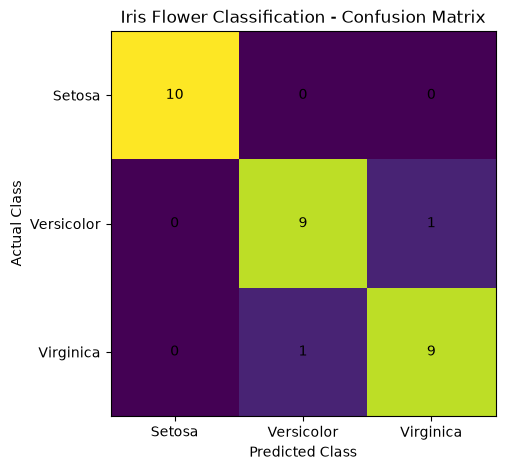

In [38]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Iris Flower Classification - Confusion Matrix")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1, 2],
    ["Setosa", "Versicolor", "Virginica"]
)

plt.yticks(
    [0, 1, 2],
    ["Setosa", "Versicolor", "Virginica"]
)

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [39]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]

In [41]:
new_flower_scaled = scaler.transform(new_flower)


prediction = model.predict(new_flower_scaled)


print("\n===================================")
print("NEW FLOWER PREDICTION")
print("===================================")

print("Predicted Species:", prediction[0])


NEW FLOWER PREDICTION
Predicted Species: setosa


c:\Users\welcome\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
